#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 10. Opening Price Gap Analysis

In [4]:
price_df = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    dtype={"stock_code": str},
    low_memory=False
)

price_df["stock_code"] = price_df["stock_code"].astype(str).str.zfill(6)
price_df["date"] = pd.to_datetime(price_df["date"])

print(price_df.columns.tolist())
print(price_df.shape)
print(price_df.head(3))

['date', 'open', 'high', 'low', 'close', 'volume', 'change', 'stock_code']
(1657925, 8)
        date   open   high    low  close  volume    change stock_code
0 2018-07-02  62116  63317  61515  61716  103017 -0.004308     285130
1 2018-07-03  61916  62249  60648  61049   72274 -0.010808     285130
2 2018-07-04  60515  62850  60515  61516   75423  0.007650     285130


In [5]:
print(price_df.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'volume', 'change', 'stock_code']


Stock price data loaded: (1657925, 8)
Analysis sample size before gap calculation: 8,551

Calculating opening price gap returns...
Gap return calculation completed: 8,551 observations

=== Descriptive Statistics: Opening Price Gap Returns ===
count    8551.0000
mean        0.0020
std         0.0188
min        -0.0557
25%        -0.0062
50%         0.0000
75%         0.0089
max         0.0770
Name: gap_return, dtype: float64

=== Mean Opening Price Gap Returns by News Type and Disclosure Timing ===
     news      timing  mean_gap  median_gap    n  mean_gap_pct  median_gap_pct
Good News  Pre-market     0.013       0.010  330         1.328           1.024
Good News    Intraday     0.002       0.000 2460         0.153           0.000
Good News After-hours     0.011       0.006 1737         1.094           0.642
 Bad News  Pre-market    -0.001       0.000  243        -0.089           0.000
 Bad News    Intraday     0.001       0.000 1894         0.057           0.000
 Bad News After-hours  

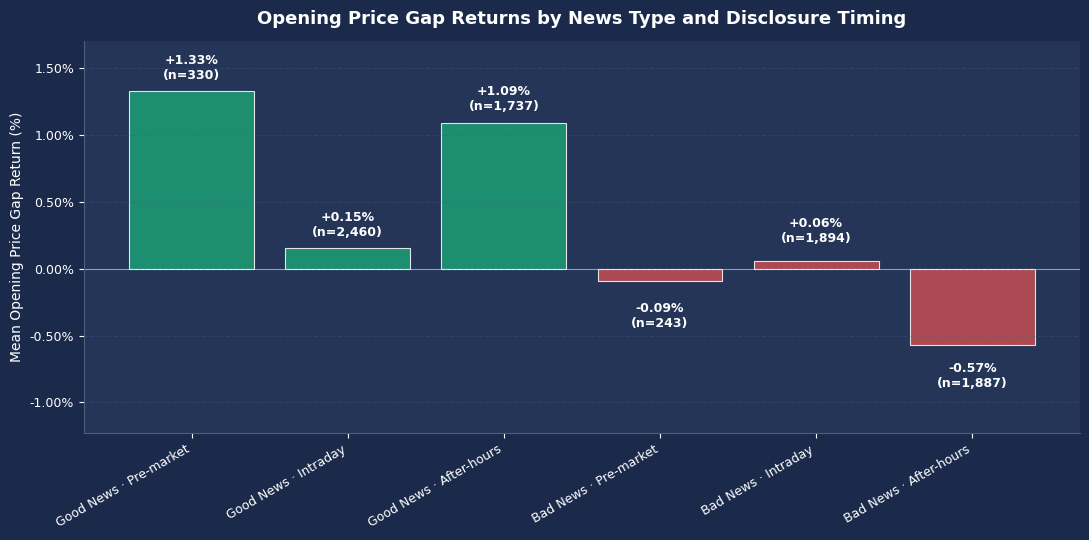

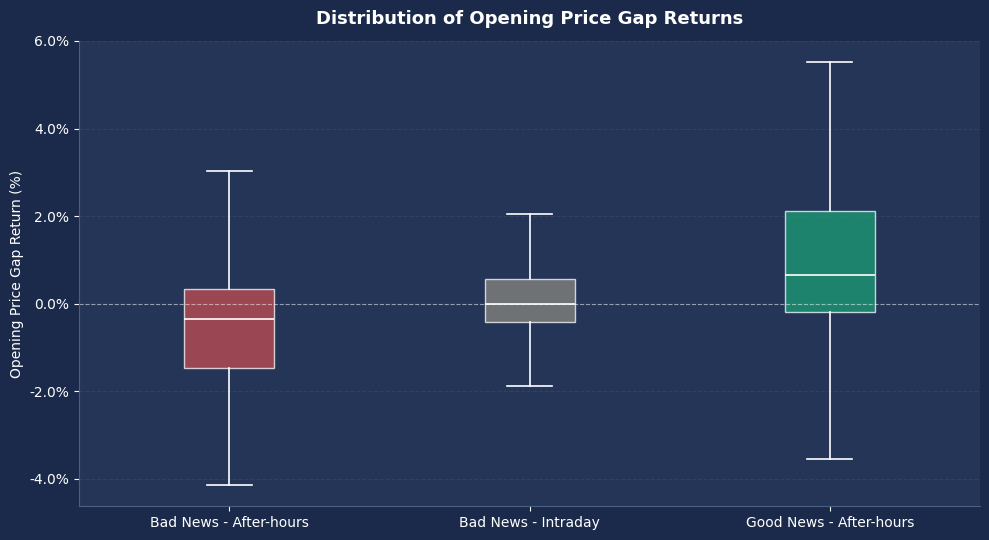


Saved output files:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\10_gap_by_news_timing.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\10_gap_boxplot.png


In [6]:
# ============================================================
# 10. Opening Price Gap Analysis
# - Analyze opening price gaps following after-hours bad-news disclosures
# - Gap return = (next open - previous close) / previous close
# ============================================================


# ------------------------------------------------------------
# 1. Load stock price data
# ------------------------------------------------------------

price_df = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    dtype={"stock_code": str},
    low_memory=False
)

price_df["stock_code"] = (
    price_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

price_df["date"] = pd.to_datetime(
    price_df["date"]
)

price_df["open"] = pd.to_numeric(
    price_df["open"],
    errors="coerce"
)

price_df["close"] = pd.to_numeric(
    price_df["close"],
    errors="coerce"
)

price_df = price_df.dropna(
    subset=["stock_code", "date", "open", "close"]
)

price_df = (
    price_df
    .sort_values(["stock_code", "date"])
    .reset_index(drop=True)
)


price_by_stock = {
    code: g.reset_index(drop=True)
    for code, g in price_df.groupby("stock_code")
}


print(f"Stock price data loaded: {price_df.shape}")


# ------------------------------------------------------------
# 2. Prepare event data
# ------------------------------------------------------------

gap_df = df_hb.copy()


# Standardize news labels
news_map = {
    "호재": "Good News",
    "악재": "Bad News",
    "Good News": "Good News",
    "Bad News": "Bad News",
    "good": "Good News",
    "bad": "Bad News"
}

gap_df["news_std"] = (
    gap_df["news"]
    .astype(str)
    .str.strip()
    .replace(news_map)
)


# Standardize disclosure timing labels
timing_map = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours",
    "Pre-market": "Pre-market",
    "Pre-Market": "Pre-market",
    "Premarket": "Pre-market",
    "Pre Market": "Pre-market",
    "Intraday": "Intraday",
    "Intra-day": "Intraday",
    "After-hours": "After-hours",
    "After-Hours": "After-hours",
    "After Hours": "After-hours",
    "After Market": "After-hours"
}

gap_df["timing_std"] = (
    gap_df["timing"]
    .astype(str)
    .str.strip()
    .replace(timing_map)
)


# Keep only valid news and timing observations
gap_df = gap_df[
    gap_df["news_std"].isin(
        ["Good News", "Bad News"]
    )
    &
    gap_df["timing_std"].isin(
        ["Pre-market", "Intraday", "After-hours"]
    )
].copy()


print(
    f"Analysis sample size before gap calculation: "
    f"{len(gap_df):,}"
)

if len(gap_df) == 0:
    raise ValueError(
        "No valid observations remain after filtering. "
        "Check the unique values in the 'news' and 'timing' columns."
    )


gap_df["stock_code"] = (
    gap_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

gap_df["rcept_dt_dt"] = pd.to_datetime(
    gap_df["rcept_dt"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)


gap_df["after_dummy"] = (
    gap_df["timing_std"] == "After-hours"
).astype(int)

gap_df["bad_dummy"] = (
    gap_df["news_std"] == "Bad News"
).astype(int)


# Create Friday dummy
if "weekday" in gap_df.columns:

    weekday_numeric = pd.to_numeric(
        gap_df["weekday"],
        errors="coerce"
    )

    if weekday_numeric.notna().any():

        gap_df["fri_dummy"] = (
            weekday_numeric == 4
        ).astype(int)

    else:

        gap_df["fri_dummy"] = (
            gap_df["weekday"]
            .astype(str)
            .str.strip()
            .str.lower()
            .isin(["friday", "fri", "금요일"])
        ).astype(int)

else:

    gap_df["fri_dummy"] = (
        gap_df["rcept_dt_dt"].dt.weekday == 4
    ).astype(int)


# Market-capitalization tertiles
if "log_marcap" in gap_df.columns:

    gap_df["log_marcap"] = pd.to_numeric(
        gap_df["log_marcap"],
        errors="coerce"
    )

    try:

        gap_df["size_group"] = pd.qcut(
            gap_df["log_marcap"],
            q=3,
            labels=[
                "Small-cap",
                "Mid-cap",
                "Large-cap"
            ]
        )

    except ValueError:

        print(
            "Market-capitalization groups could not be created "
            "because there are insufficient unique values."
        )


# ------------------------------------------------------------
# 3. Define opening price gap calculation
# ------------------------------------------------------------

def calc_gap(stock_code, event_date, after_dummy):

    stock_data = price_by_stock.get(stock_code)

    if (
        stock_data is None
        or len(stock_data) < 2
        or pd.isna(event_date)
    ):
        return np.nan


    dates = stock_data["date"].values


    # After-hours disclosure:
    # the next trading day's opening price represents
    # the first market reaction.
    if after_dummy == 1:

        # Closing price on the disclosure date
        idx = np.searchsorted(
            dates,
            np.datetime64(event_date),
            side="left"
        )

        if idx >= len(stock_data) - 1:
            return np.nan

        close_price = stock_data.loc[
            idx,
            "close"
        ]

        open_price = stock_data.loc[
            idx + 1,
            "open"
        ]


    # Intraday / pre-market disclosure:
    # compare the previous trading day's close
    # with the disclosure day's opening price.
    else:

        idx = np.searchsorted(
            dates,
            np.datetime64(event_date),
            side="left"
        )

        if idx == 0 or idx >= len(stock_data):
            return np.nan

        close_price = stock_data.loc[
            idx - 1,
            "close"
        ]

        open_price = stock_data.loc[
            idx,
            "open"
        ]


    if (
        pd.isna(close_price)
        or pd.isna(open_price)
        or close_price <= 0
    ):
        return np.nan


    return (
        (open_price - close_price)
        / close_price
    )


# ------------------------------------------------------------
# 4. Calculate opening price gap returns
# ------------------------------------------------------------

print(
    "\nCalculating opening price gap returns..."
)


gap_df["gap_return"] = gap_df.apply(
    lambda x: calc_gap(
        stock_code=x["stock_code"],
        event_date=x["rcept_dt_dt"],
        after_dummy=x["after_dummy"]
    ),
    axis=1
)


gap_df = gap_df.dropna(
    subset=["gap_return"]
).copy()


if len(gap_df) == 0:
    raise ValueError(
        "No valid opening price gap returns were calculated. "
        "Check stock codes, disclosure dates, and stock price dates."
    )


# Winsorize extreme values at the 1st and 99th percentiles
lower = gap_df["gap_return"].quantile(0.01)
upper = gap_df["gap_return"].quantile(0.99)

gap_df["gap_return"] = (
    gap_df["gap_return"]
    .clip(lower, upper)
)


print(
    f"Gap return calculation completed: "
    f"{len(gap_df):,} observations"
)

print(
    "\n=== Descriptive Statistics: Opening Price Gap Returns ==="
)

print(
    gap_df["gap_return"]
    .describe()
    .round(4)
)


# ------------------------------------------------------------
# 5. Mean opening price gap returns by group
# ------------------------------------------------------------

group_gap = (
    gap_df
    .groupby(
        ["news_std", "timing_std"],
        observed=False
    )["gap_return"]
    .agg(
        ["mean", "median", "count"]
    )
    .reset_index()
)


group_gap.columns = [
    "news",
    "timing",
    "mean_gap",
    "median_gap",
    "n"
]


group_gap["mean_gap_pct"] = (
    group_gap["mean_gap"] * 100
)

group_gap["median_gap_pct"] = (
    group_gap["median_gap"] * 100
)


# Set explicit category order
news_order = [
    "Good News",
    "Bad News"
]

timing_order = [
    "Pre-market",
    "Intraday",
    "After-hours"
]


group_gap["news"] = pd.Categorical(
    group_gap["news"],
    categories=news_order,
    ordered=True
)

group_gap["timing"] = pd.Categorical(
    group_gap["timing"],
    categories=timing_order,
    ordered=True
)

group_gap = (
    group_gap
    .sort_values(
        ["news", "timing"]
    )
    .reset_index(drop=True)
)


print(
    "\n=== Mean Opening Price Gap Returns "
    "by News Type and Disclosure Timing ==="
)

print(
    group_gap
    .round(3)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. Key comparison tests
# ------------------------------------------------------------

def ttest_groups(
    df,
    col,
    mask1,
    mask2,
    label1,
    label2
):

    g1 = (
        df.loc[mask1, col]
        .dropna()
    )

    g2 = (
        df.loc[mask2, col]
        .dropna()
    )


    print(
        f"\n[{label1}] vs [{label2}]"
    )


    if len(g1) < 2 or len(g2) < 2:

        print(
            "  Test could not be performed: "
            "insufficient observations."
        )

        return np.nan, np.nan


    t, p = stats.ttest_ind(
        g1,
        g2,
        equal_var=False,
        nan_policy="omit"
    )


    print(
        f"  Mean: "
        f"{g1.mean() * 100:.3f}% "
        f"vs "
        f"{g2.mean() * 100:.3f}%"
    )

    print(
        f"  Difference: "
        f"{(g1.mean() - g2.mean()) * 100:+.3f}%p"
    )

    print(
        f"  t = {t:.3f}, "
        f"p = {p:.4f} "
        f"{'(Significant)' if p < 0.05 else '(Not significant)'}"
    )


    return t, p


print(
    "\n=== Key Comparison Tests ==="
)


# 1. Bad News - After-hours vs Bad News - Intraday
ttest_groups(
    gap_df,
    "gap_return",

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
    ),

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "Intraday")
    ),

    "Bad News - After-hours",
    "Bad News - Intraday"
)


# 2. Bad News - After-hours vs Good News - After-hours
ttest_groups(
    gap_df,
    "gap_return",

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
    ),

    (
        (gap_df["news_std"] == "Good News")
        &
        (gap_df["timing_std"] == "After-hours")
    ),

    "Bad News - After-hours",
    "Good News - After-hours"
)


# 3. Friday Bad News - After-hours
#    vs Non-Friday Bad News - After-hours
ttest_groups(
    gap_df,
    "gap_return",

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
        &
        (gap_df["fri_dummy"] == 1)
    ),

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
        &
        (gap_df["fri_dummy"] == 0)
    ),

    "Friday Bad News - After-hours",
    "Non-Friday Bad News - After-hours"
)


# 4. Small-cap Bad News - After-hours
#    vs Large-cap Bad News - After-hours
if "size_group" in gap_df.columns:

    ttest_groups(
        gap_df,
        "gap_return",

        (
            (gap_df["news_std"] == "Bad News")
            &
            (gap_df["timing_std"] == "After-hours")
            &
            (gap_df["size_group"] == "Small-cap")
        ),

        (
            (gap_df["news_std"] == "Bad News")
            &
            (gap_df["timing_std"] == "After-hours")
            &
            (gap_df["size_group"] == "Large-cap")
        ),

        "Small-cap Bad News - After-hours",
        "Large-cap Bad News - After-hours"
    )


# ------------------------------------------------------------
# 7. Visualization 1:
#    Mean opening price gap returns by group
# ------------------------------------------------------------

BG_COLOR = "#1B2A4A"


fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


group_gap["label"] = (
    group_gap["news"].astype(str)
    + " · "
    + group_gap["timing"].astype(str)
)


colors = [
    "#1D9E75"
    if news == "Good News"
    else "#C44E52"
    for news in group_gap["news"]
]


bars = ax.bar(
    group_gap["label"],
    group_gap["mean_gap_pct"],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


y_min = group_gap["mean_gap_pct"].min()
y_max = group_gap["mean_gap_pct"].max()
y_range = y_max - y_min


ax.set_ylim(
    y_min - max(
        0.25,
        y_range * 0.35
    ),
    y_max + max(
        0.25,
        y_range * 0.20
    )
)


# Adjust label positions to prevent overlap
for i, (bar, val, n) in enumerate(
    zip(
        bars,
        group_gap["mean_gap_pct"],
        group_gap["n"]
    )
):

    x = (
        bar.get_x()
        + bar.get_width() / 2
    )


    if val >= 0:

        y = val + 0.07
        va = "bottom"

    else:

        y = val - 0.13
        va = "top"


    if abs(val) < 0.12:

        if val >= 0:

            y = val + 0.12
            va = "bottom"

        else:

            y = val - 0.16
            va = "top"


    ax.text(
        x,
        y,
        f"{val:+.2f}%\n"
        f"(n={int(n):,})",
        ha="center",
        va=va,
        fontsize=9,
        fontweight="bold",
        color="white",
        clip_on=False
    )


ax.axhline(
    0,
    color="white",
    linewidth=0.8,
    alpha=0.5
)


ax.set_ylabel(
    "Mean Opening Price Gap Return (%)",
    fontsize=10,
    color="white"
)


ax.set_title(
    "Opening Price Gap Returns "
    "by News Type and Disclosure Timing",
    fontsize=13,
    fontweight="bold",
    pad=12,
    color="white"
)


ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter("%.2f%%")
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color(
    "#4A6080"
)


ax.tick_params(
    axis="x",
    colors="white",
    labelsize=9
)

ax.tick_params(
    axis="y",
    colors="white",
    labelsize=9
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()


plt.savefig(
    OUTPUT_DIR /
    "10_gap_by_news_timing.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 8. Visualization 2:
#    Distribution of opening price gap returns
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


plot_groups = [

    (
        "Bad News - After-hours",

        (
            (gap_df["news_std"] == "Bad News")
            &
            (gap_df["timing_std"] == "After-hours")
        ),

        "#C44E52"
    ),

    (
        "Bad News - Intraday",

        (
            (gap_df["news_std"] == "Bad News")
            &
            (gap_df["timing_std"] == "Intraday")
        ),

        "#888780"
    ),

    (
        "Good News - After-hours",

        (
            (gap_df["news_std"] == "Good News")
            &
            (gap_df["timing_std"] == "After-hours")
        ),

        "#1D9E75"
    )
]


plot_data = [
    gap_df.loc[
        mask,
        "gap_return"
    ].dropna() * 100

    for _, mask, _ in plot_groups
]


plot_labels = [
    label
    for label, _, _ in plot_groups
]

plot_colors = [
    color
    for _, _, color in plot_groups
]


# Compatible with both newer and older Matplotlib versions
try:

    box = ax.boxplot(
        plot_data,
        tick_labels=plot_labels,
        patch_artist=True,
        showfliers=False
    )

except TypeError:

    box = ax.boxplot(
        plot_data,
        labels=plot_labels,
        patch_artist=True,
        showfliers=False
    )


for patch, color in zip(
    box["boxes"],
    plot_colors
):

    patch.set_facecolor(
        color
    )

    patch.set_alpha(
        0.75
    )

    patch.set_edgecolor(
        "white"
    )


for element in [
    "whiskers",
    "caps",
    "medians"
]:

    for item in box[element]:

        item.set_color(
            "white"
        )

        item.set_linewidth(
            1.2
        )


ax.axhline(
    0,
    color="white",
    linewidth=0.8,
    alpha=0.5,
    linestyle="--"
)


ax.set_ylabel(
    "Opening Price Gap Return (%)",
    fontsize=10
)


ax.set_title(
    "Distribution of Opening Price Gap Returns",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color(
    "#4A6080"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR /
    "10_gap_boxplot.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 9. Saved output files
# ------------------------------------------------------------

print(
    "\nSaved output files:"
)

print(
    OUTPUT_DIR /
    "10_gap_by_news_timing.png"
)

print(
    OUTPUT_DIR /
    "10_gap_boxplot.png"
)

In [7]:
# ------------------------------------------------------------
# Merge market capitalization data
# ------------------------------------------------------------

if "log_marcap" not in gap_df.columns:

    raw_comp_gap = raw_comp.copy()

    raw_comp_gap["stock_code"] = (
        raw_comp_gap["stock_code"]
        .astype(str)
        .str.zfill(6)
    )

    gap_df = gap_df.merge(
        raw_comp_gap[
            ["stock_code", "log_marcap"]
        ]
        .drop_duplicates(subset="stock_code"),
        on="stock_code",
        how="left"
    )


gap_df["log_marcap"] = pd.to_numeric(
    gap_df["log_marcap"],
    errors="coerce"
)


print(
    f"Missing rate for log_marcap: "
    f"{gap_df['log_marcap'].isna().mean() * 100:.1f}%"
)


# ------------------------------------------------------------
# Classify firms into market-capitalization tertiles
# ------------------------------------------------------------

gap_df["size_group"] = pd.qcut(
    gap_df["log_marcap"],
    q=3,
    labels=[
        "Small-cap",
        "Mid-cap",
        "Large-cap"
    ]
)


print(
    "\n=== Market Capitalization Groups ==="
)

print(
    gap_df["size_group"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Compare opening price gaps:
# Small-cap vs Large-cap bad-news after-hours disclosures
# ------------------------------------------------------------

ttest_groups(
    gap_df,
    "gap_return",

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
        &
        (gap_df["size_group"] == "Small-cap")
    ),

    (
        (gap_df["news_std"] == "Bad News")
        &
        (gap_df["timing_std"] == "After-hours")
        &
        (gap_df["size_group"] == "Large-cap")
    ),

    "Small-cap Bad News - After-hours",
    "Large-cap Bad News - After-hours"
)

Missing rate for log_marcap: 0.0%

=== Market Capitalization Groups ===
size_group
Small-cap    2857
Mid-cap      2845
Large-cap    2849
Name: count, dtype: int64

[Small-cap Bad News - After-hours] vs [Large-cap Bad News - After-hours]
  Mean: -0.618% vs -0.496%
  Difference: -0.122%p
  t = -1.050, p = 0.2938 (Not significant)


(np.float64(-1.0503328473106153), np.float64(0.29378410557032414))

# 10. Analysis of Disclosure Timing and Opening Price Gap Returns

## 10.1. Objective

This section examines how disclosure timing and information direction (good news vs. bad news) are associated with opening price gap returns.

In particular, the analysis tests whether after-hours disclosures are associated with stronger opening price reactions, as investors have more time to process and disseminate information before the next trading session.

Accordingly, mean opening price gap returns are compared across news types and disclosure timing categories.

---

## 10.2. Descriptive Statistics

The results show that after-hours disclosures are associated with substantially larger opening price gap returns in absolute terms than intraday disclosures.

| Disclosure Type | Mean Opening Price Gap Return |
|---|---:|
| Bad News - Pre-market | -0.089% |
| Bad News - Intraday | +0.057% |
| Bad News - After-hours | -0.567% |
| Good News - Pre-market | +1.328% |
| Good News - Intraday | +0.153% |
| Good News - After-hours | +1.094% |

Bad-news after-hours disclosures exhibit a pronounced negative opening price gap, while good-news after-hours disclosures are associated with a substantial positive gap.

By contrast, intraday disclosures show relatively small opening price gaps for both good and bad news.

This pattern is consistent with the interpretation that information released during trading hours may already be partially incorporated into prices during the same trading session, whereas information released after market close is reflected more directly in the opening price of the next trading session.

---

## 10.3. Mean Difference Tests

### (1) Bad News - After-hours vs. Bad News - Intraday

Bad-news after-hours disclosures are associated with significantly lower opening price gap returns than bad-news intraday disclosures.

```text
Bad News - After-hours: -0.567%
Bad News - Intraday:    +0.057%
Difference:             -0.624%p

t = -11.741
p < 0.001
```

The difference is statistically significant, indicating that bad news disclosed after market hours is associated with a substantially more negative opening price reaction than bad news disclosed during trading hours.

---

### (2) Bad News - After-hours vs. Good News - After-hours

A substantial difference is also observed between bad-news and good-news after-hours disclosures.

```text
Bad News - After-hours:  -0.567%
Good News - After-hours: +1.094%
Difference:              -1.661%p

t = -22.221
p < 0.001
```

This result indicates that opening price reactions to after-hours disclosures differ substantially according to the direction of the disclosed information.

In particular, good news released after market hours is associated with a strong positive opening price gap, whereas bad news is associated with a negative opening price gap.

---

## 10.4. Additional Tests

### (1) Friday After-hours Bad-News Effect

Friday after-hours bad-news disclosures exhibit a more negative mean opening price gap than non-Friday after-hours bad-news disclosures, but the difference is not statistically significant.

```text
Friday Bad News - After-hours:     -0.663%
Non-Friday Bad News - After-hours: -0.537%
Difference:                        -0.126%p

t = -1.126
p = 0.261
```

Thus, the results provide no statistically significant evidence that the additional information-processing time over the weekend produces a larger negative opening price gap.

---

### (2) Differences by Market Capitalization

Small-cap firms with bad-news after-hours disclosures exhibit a more negative mean opening price gap than large-cap firms, but the difference is not statistically significant.

```text
Small-cap Bad News - After-hours: -0.618%
Large-cap Bad News - After-hours: -0.496%
Difference:                       -0.122%p

t = -1.050
p = 0.294
```

Therefore, the results provide no statistically significant evidence that the opening price gap associated with bad-news after-hours disclosures differs systematically between small- and large-cap firms.

---

## 10.5. Distributional Characteristics

The boxplot analysis shows that the distribution of opening price gap returns for good-news after-hours disclosures is shifted toward positive values.

By contrast, bad-news after-hours disclosures exhibit a negative median and a relatively extended lower tail.

This pattern suggests that bad-news after-hours disclosures are associated not only with a more negative average opening price reaction but also with the possibility of relatively large negative opening gaps for some firms.

The distributional evidence therefore highlights potential downside risk in addition to differences in mean opening price responses.

---

## 10.6. Overall Interpretation

Overall, the results indicate a strong association between disclosure timing, information direction, and opening price reactions.

After-hours disclosures exhibit substantially larger opening price gaps in absolute terms than intraday disclosures, with the direction of the reaction differing clearly between good and bad news. Bad news released after market hours is associated with a significant negative opening price gap, whereas good news released after market hours is associated with a substantial positive gap.

The results are consistent with a market-adjustment mechanism in which information released during trading hours can be incorporated into prices before the market closes, while information released after market close is reflected more directly in the opening price of the next trading session.

However, the Friday and market-capitalization subgroup tests do not provide statistically significant evidence of additional heterogeneity within bad-news after-hours disclosures.

Taken together, these findings suggest that after-hours disclosure timing is systematically associated with the concentration of price adjustment at the next market opening. Because the analysis is observational, however, the results should be interpreted as evidence of association rather than as causal evidence that after-hours disclosure itself produces the observed price reactions.